## Step 1-> Understanding the problem
#### 📝 Customer churn means when a customer stops using a service or leaves a company.

#### 🎯 Why companies care?
1. Getting new customer = expensive 💰
2. Retaining customer = cheaper ✔️

#### 👉 So companies:
1. Predict churn
2. Take action early

#### 🎯 Goal of this project -> Build a model that predicts whether a customer will churn or not

## 🚀 STEP 2: Get Dataset

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("Customer churn kaggle data.csv")

## ⚡ Step 3: EDA

In [2]:
#df.head()
#df.info() # dtypes: float64(1), int64(2), object(18)
#df.shape # 7043 rows and 21 columns
#df.isnull().sum() # No null values in dataset
df['Churn'].value_counts() #Counts the number of different categories in the feature

No     5174
Yes    1869
Name: Churn, dtype: int64

## 🚀 Step4: DATA CLEANING + ENCODING

In [3]:
df.select_dtypes(include = 'object').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

### 🧠 1: Identify Problems in Your Columns

#### ❗TotalCharges (VERY IMPORTANT)

👉 Currently object ❌

👉 But should be numeric ✔️

In [4]:
#Empty space or non numeric values are transformed into NaN preventing errors and ensuring the column can be used for calculations.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce') 

In [5]:
df['TotalCharges'].isnull().sum() # We got 11 NaN
df = df.dropna()

### 🧠 2: Remove unnecessary column

In [6]:
df = df.drop('customerID', axis = 1)

### 🧠 3: Handle Target Column

In [7]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### 🧠 4: Encoding Features

### 🧠 What this does:
Converts ALL categorical → numeric

Avoids dummy variable trap

In [8]:
df = pd.get_dummies(df, drop_first = True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   uint8  
 6   Partner_Yes                            7032 non-null   uint8  
 7   Dependents_Yes                         7032 non-null   uint8  
 8   PhoneService_Yes                       7032 non-null   uint8  
 9   MultipleLines_No phone service         7032 non-null   uint8  
 10  MultipleLines_Yes                      7032 non-null   uint8  
 11  Inte

## 🎯 Step 5: Separate Features & Target

In [10]:
x = df.drop('Churn', axis = 1)
y = df['Churn']

## 🎯 Step 6: Train-Test Split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

## 🎯 Step 7: Train Model LogisticRegression

### class_weight = 'balaced', since we have the dataset which is not balanced so we need to balance it so that we can improve the perfromance and give high recall, It works by assigning higher weights to minority classes and lower weights to majority classes, using the formula \(n_{samples} / (n_{classes} \times \text{bincount}(y))\). This ensures the model treats all classes with equal importance during training, boosting minority class recall

In [31]:
model = LogisticRegression(max_iter = 1000, class_weight = 'balanced')
model.fit(x_train, y_train)
print(len(x_test))

1407


## 🎯 Step 8: Predict

In [58]:
# y_pred = model.predict(x_test) # this gives final ans class 0 or class 1
y_proba = model.predict_proba(x_test)[:,1] # take all rows but select only 2nd column because here column 0 represent class 0 and column 1 represent class 1
#print(y_proba[0:70])

### Now to improve the recall we are going to change the threshold because as we all know the default threshold is 0.5 and we are going to change it to 0.3 so it caches more churn user even if it in unsure but in this case it will give many false alarm i.e predict non churn user as churn but that's fine because we are more concerned about improving the recall

In [59]:
y_pred_new = (y_proba>0.3).astype(int) # y_prob>0.3 will give boolean array [True or False]then we are converting it into int as we all know True =1 and False = 0

## 🎯 Step 9: Evaluate Model

In [60]:
print("Accuracy:", accuracy_score(y_test, y_pred_new))

Accuracy: 0.642501776830135


In [61]:
print("Confusion matrix:", confusion_matrix(y_test, y_pred_new))

Confusion matrix: [[561 472]
 [ 31 343]]


In [62]:
print("Classification report:", classification_report(y_test, y_pred_new))

Classification report:               precision    recall  f1-score   support

           0       0.95      0.54      0.69      1033
           1       0.42      0.92      0.58       374

    accuracy                           0.64      1407
   macro avg       0.68      0.73      0.63      1407
weighted avg       0.81      0.64      0.66      1407



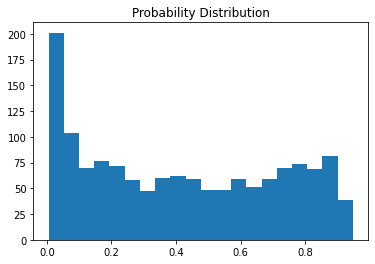

In [64]:
import matplotlib.pyplot as plt

plt.hist(y_proba, bins=20)
plt.title("Probability Distribution")
plt.show()